# Stage 2 — DRS-only baseline evaluation
This notebook consolidates the old LOSO baseline notebook. It reports subject-level calibration, RMSE, MAE and bias for HC and StO₂.

In [1]:
from pathlib import Path
import os, sys
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():  # VS Code may start in notebooks/
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
from subject_nirs.stage2.baseline_analysis import generate_thesis_figures
ARTIFACTS = Path('artifacts/stage2')
OUTPUT = Path('results/tables/stage2/baseline')

## Compute subject-level metrics
Each prediction is first aggregated within subject. The figures therefore describe LOSO generalization across subjects rather than the much larger number of simulated rows.

Saved thesis outputs to: /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/results/tables/stage2/baseline
target  n_subjects  n_samples  pooled_RMSE_secondary  pooled_MAE_secondary  pooled_Bias_secondary  pooled_R2_secondary  subject_RMSE_median  subject_RMSE_Q1  subject_RMSE_Q3  subject_RMSE_mean  subject_RMSE_SD  subject_MAE_median  subject_MAE_Q1  subject_MAE_Q3  subject_MAE_mean  subject_MAE_SD  subject_Bias_median  subject_Bias_Q1  subject_Bias_Q3  subject_Bias_mean  subject_Bias_SD  subject_R2_median  subject_R2_Q1  subject_R2_Q3  subject_R2_mean  subject_R2_SD
    HC         154    5987520              15.903810             12.436579              -0.185731             0.146357            14.033874        10.521772        17.889792          14.893295         5.596816           11.626775        8.576574       15.228940         12.436579        4.893511             1.071402        -9.824305         8.305751          -0.185731        11.691503           0.335294      -0.080193 

,target,n_subjects,n_samples,pooled_RMSE_secondary,pooled_MAE_secondary,pooled_Bias_secondary,pooled_R2_secondary,subject_RMSE_median,subject_RMSE_Q1,subject_RMSE_Q3,...,subject_Bias_median,subject_Bias_Q1,subject_Bias_Q3,subject_Bias_mean,subject_Bias_SD,subject_R2_median,subject_R2_Q1,subject_R2_Q3,subject_R2_mean,subject_R2_SD
0,HC,154,5987520,15.903810,12.436579,-0.185731,0.146357,14.033874,10.521772,17.889792,...,1.071402,-9.824305,8.305751,-0.185731,11.691503,0.335294,-0.080193,0.626247,0.146357,0.661158
1,StO2,154,5987520,0.060639,0.044902,0.003304,0.748594,0.045467,0.035095,0.069571,...,0.002773,-0.026043,0.026284,0.003304,0.041062,0.858657,0.669066,0.915787,0.748594,0.252391


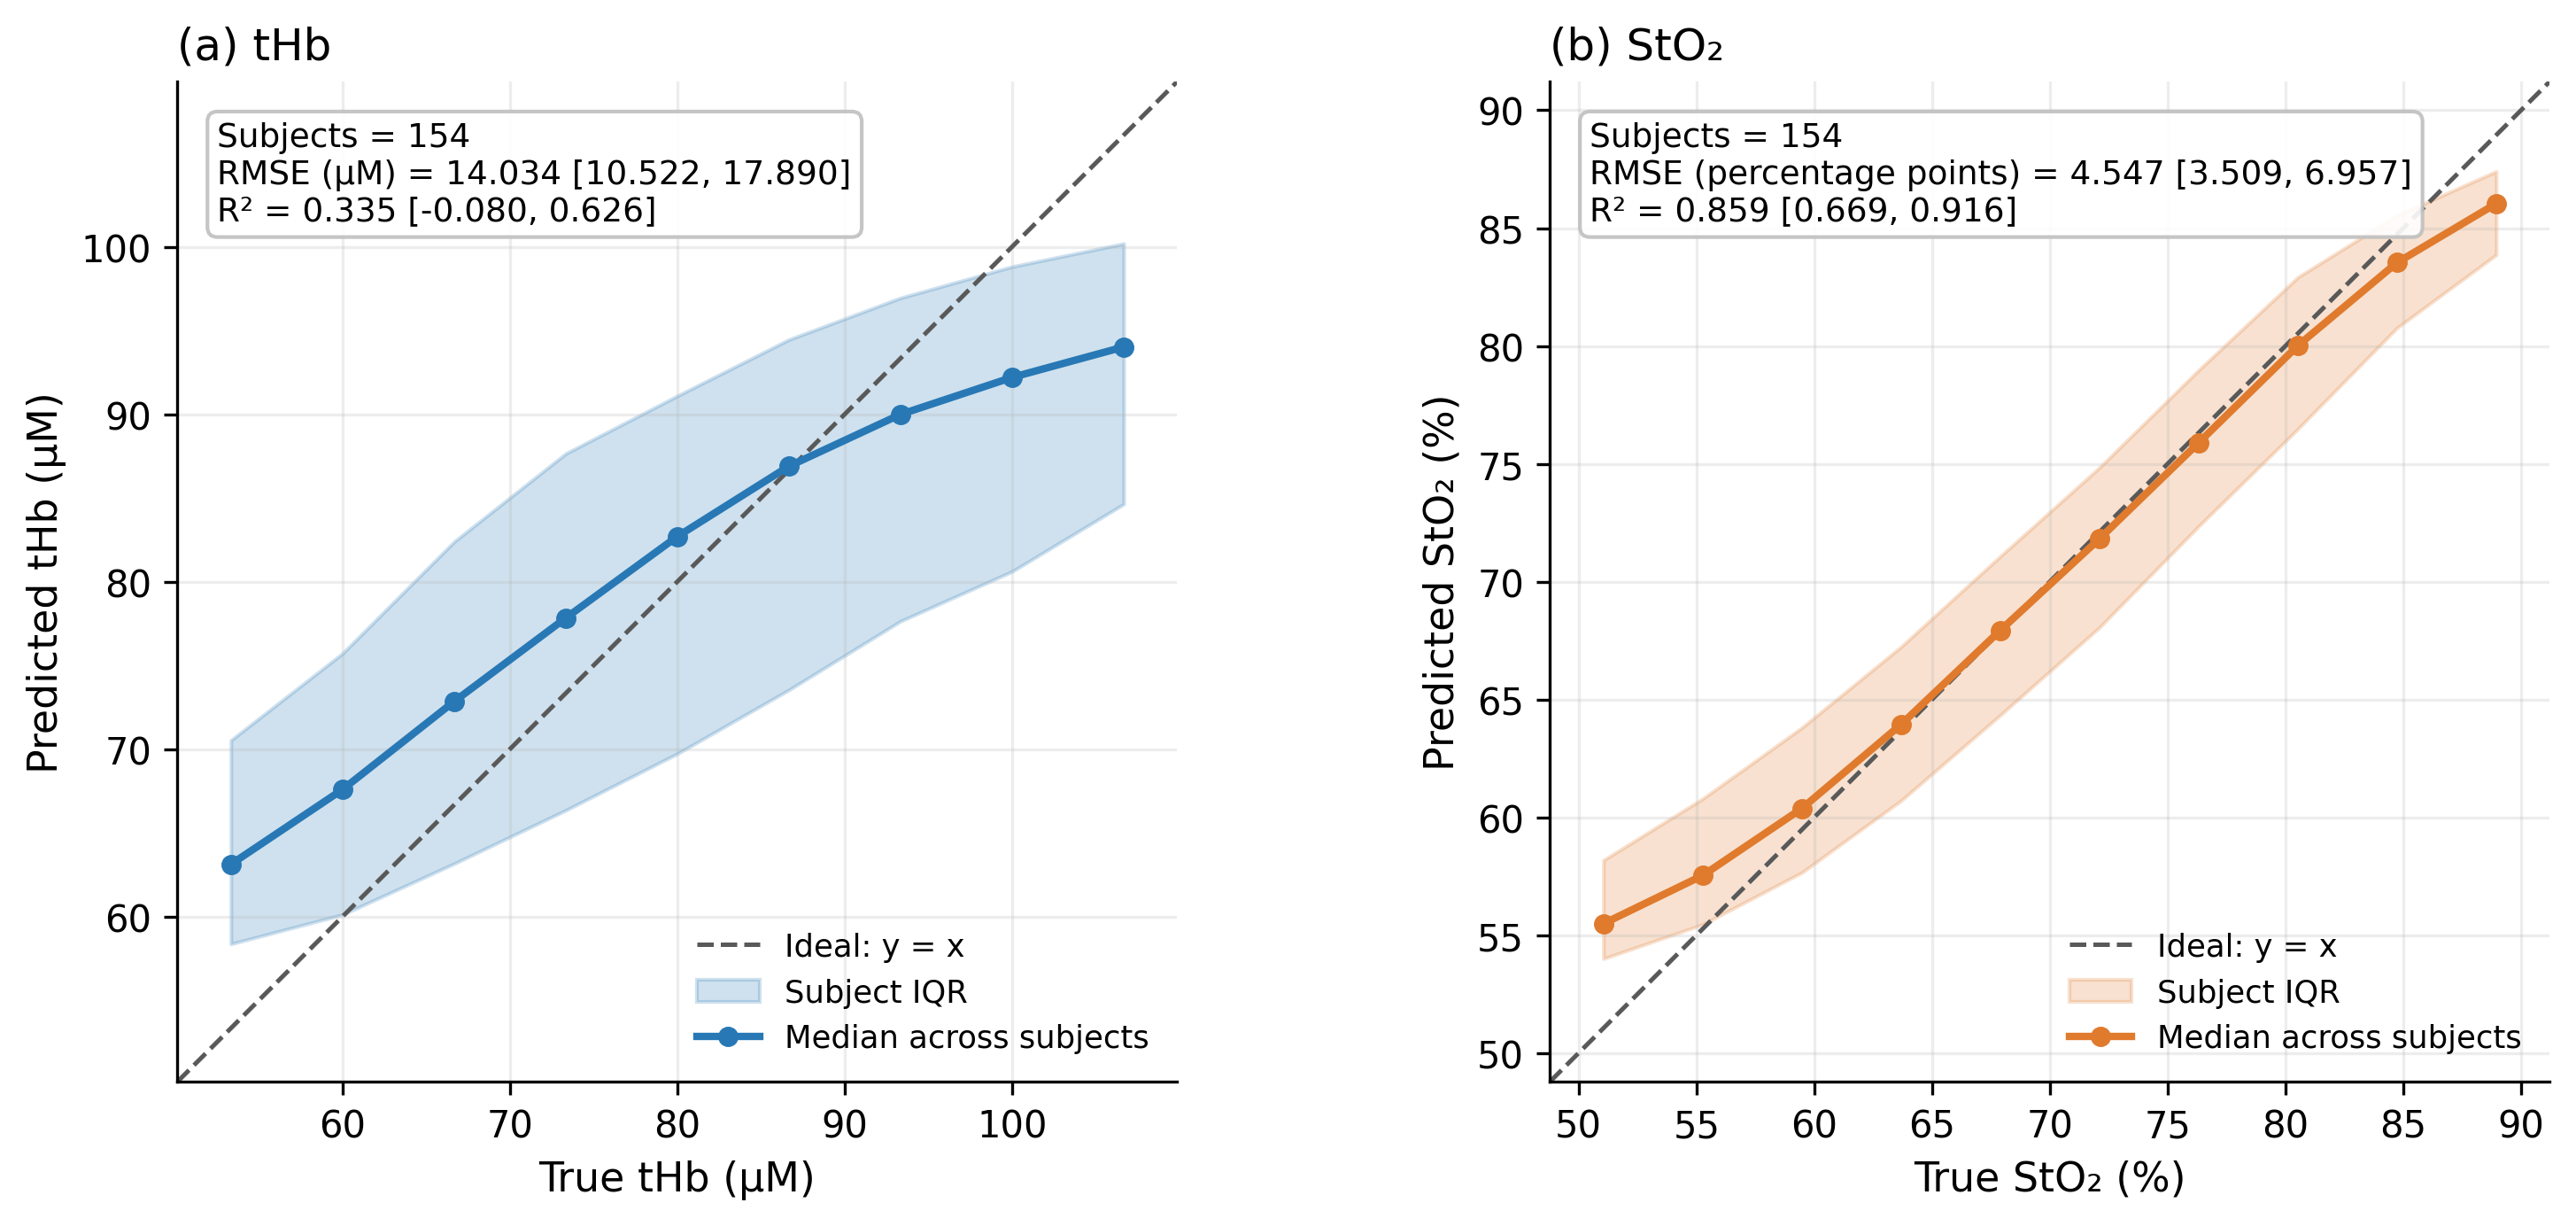

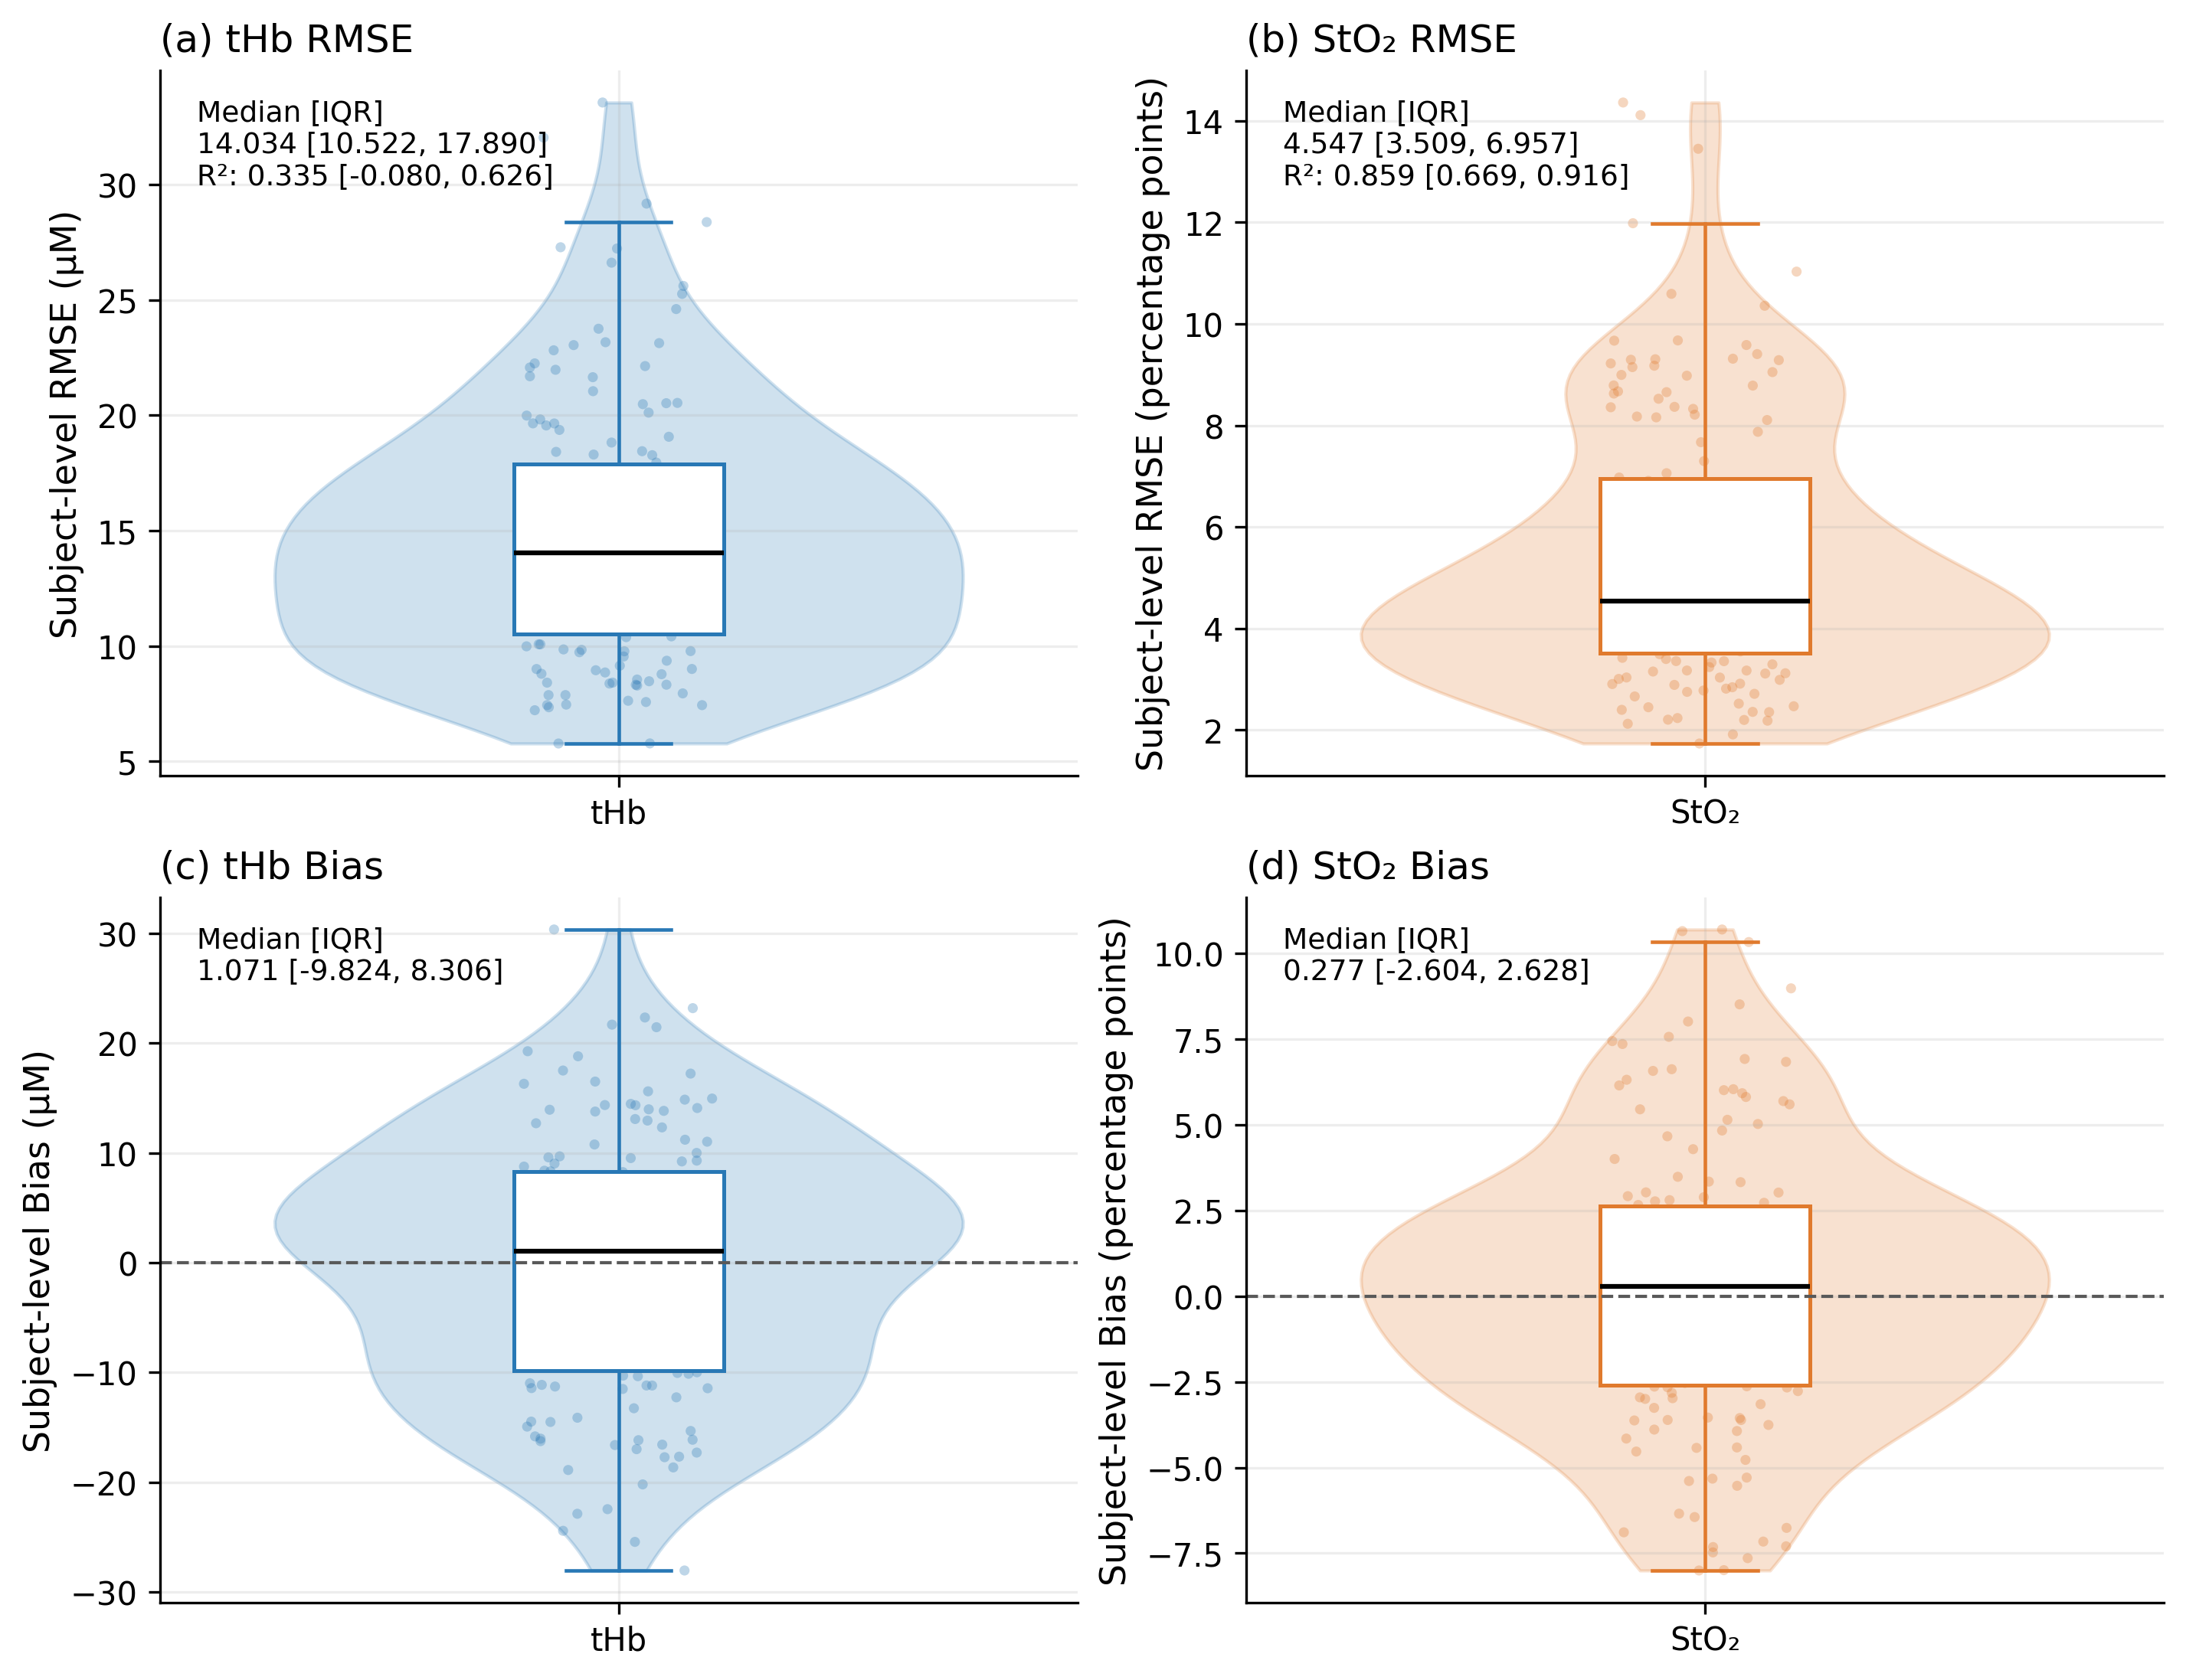

In [2]:
from IPython.display import Image, display

HC_DIR = ARTIFACTS / 'baseline/hc'
STO2_DIR = ARTIFACTS / 'baseline/sto2'
missing = [path / 'loso_results.csv' for path in (HC_DIR, STO2_DIR) if not (path / 'loso_results.csv').is_file()]
if missing:
    raise FileNotFoundError(f'Run the Stage 2 baseline LOSO experiments first. Missing: {missing}')
result = generate_thesis_figures(
    hc_dir=HC_DIR,
    sto2_dir=STO2_DIR,
    output_dir=OUTPUT, show=False,
)
display(result['summary'])
for figure_name in ('baseline_calibration.png', 'subject_error_distribution.png'):
    display(Image(filename=str(OUTPUT / figure_name), width=1100))
